#**Real-Time Ferry Ticket Sales & Redemption Analytics for Toronto Island Park**

**Project Objective**

This project analyzes real-time ferry ticket sales and redemption data for Toronto Island Park to identify passenger demand patterns, peak travel periods, seasonal trends, and operational opportunities. The analysis aims to support data-driven decision-making for ferry scheduling, capacity planning, and passenger experience optimization.

####**Data Preparation & Feature Engineering**

**Import Required Libraries**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [51]:
df = pd.read_excel("Toronto Island Ferry Tickets.csv.xlsx")
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


**Dataset Overview**

In [52]:
print("Dataset Shape:", df.shape)
df.info()
df.describe()

Dataset Shape: (261538, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


,_id,Redemption Count,Sales Count
count,261538.000000,261538.000000,261538.000000
mean,130769.500000,48.885030,49.599106
std,75499.661689,104.549336,99.862285
min,1.000000,0.000000,0.000000
25%,65385.250000,3.000000,3.000000
50%,130769.500000,11.000000,13.000000
75%,196153.750000,40.000000,48.000000
max,261538.000000,7216.000000,7229.000000


**Dataset Insight**

The dataset contains ferry ticket sales and redemption transactions recorded at 15-minute intervals. The large volume of records enables detailed analysis of passenger demand patterns, operational trends, and seasonal variations.

**Data Quality Assessment**

In [53]:
print("Missing Values")
print(df.isnull().sum())
print("\nDuplicate Records")
print(df.duplicated().sum())

Missing Values
_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

Duplicate Records
0


**Data Quality Insight**

Data quality assessment was conducted to identify missing values and duplicate records. Clean and reliable data is essential for generating accurate operational insights and supporting effective decision-making.

**Data Cleaning**

In [54]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp")
df.reset_index(drop=True, inplace=True)
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,261538,2015-05-01 13:30:00,0,1
1,261537,2015-05-01 15:15:00,0,2
2,261536,2015-05-01 15:45:00,0,1
3,261535,2015-05-01 16:00:00,1,0
4,261534,2015-05-04 16:00:00,0,2


**Data Cleaning Insight**

The Timestamp column was converted to datetime format and the dataset was sorted chronologically. This preparation enables accurate time-series analysis and trend identification.

**Feature Engineering**

In [55]:
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()
df["Month"] = df["Timestamp"].dt.month_name()
df["Year"] = df["Timestamp"].dt.year
df["Quarter"] = df["Timestamp"].dt.quarter
df["Weekend"] = np.where(
    df["Timestamp"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday")
df["Net Passenger Movement"] = (
    df["Sales Count"] -
    df["Redemption Count"])
df["Peak Period"] = np.where(
    (df["Hour"] >= 7) & (df["Hour"] <= 10),
    "Morning Peak",
    np.where(
        (df["Hour"] >= 16) & (df["Hour"] <= 19),
        "Evening Peak",
        "Off Peak"))
df.head()

,_id,Timestamp,Redemption Count,Sales Count,Hour,Day,Month,Year,Quarter,Weekend,Net Passenger Movement,Peak Period
0,261538,2015-05-01 13:30:00,0,1,13,Friday,May,2015,2,Weekday,1,Off Peak
1,261537,2015-05-01 15:15:00,0,2,15,Friday,May,2015,2,Weekday,2,Off Peak
2,261536,2015-05-01 15:45:00,0,1,15,Friday,May,2015,2,Weekday,1,Off Peak
3,261535,2015-05-01 16:00:00,1,0,16,Friday,May,2015,2,Weekday,-1,Evening Peak
4,261534,2015-05-04 16:00:00,0,2,16,Monday,May,2015,2,Weekday,2,Evening Peak


**Feature Engineering Insight**

Additional time-based features were created to facilitate hourly, daily, monthly, and seasonal analysis. Net Passenger Movement was calculated to evaluate differences between ticket sales and passenger redemptions, while Peak Period classification helps identify operational pressure windows.

**Engineered Features Validation**

In [56]:
df[[
"Timestamp",
"Hour",
"Day",
"Month",
"Year",
"Quarter",
"Weekend",
"Peak Period",
"Net Passenger Movement"]].head()

,Timestamp,Hour,Day,Month,Year,Quarter,Weekend,Peak Period,Net Passenger Movement
0,2015-05-01 13:30:00,13,Friday,May,2015,2,Weekday,Off Peak,1
1,2015-05-01 15:15:00,15,Friday,May,2015,2,Weekday,Off Peak,2
2,2015-05-01 15:45:00,15,Friday,May,2015,2,Weekday,Off Peak,1
3,2015-05-01 16:00:00,16,Friday,May,2015,2,Weekday,Evening Peak,-1
4,2015-05-04 16:00:00,16,Monday,May,2015,2,Weekday,Evening Peak,2


**Validation Insight**

The engineered features provide multiple analytical dimensions for understanding passenger behavior. These variables will support trend analysis, demand forecasting, operational planning, and peak period identification.

**Executive KPI Summary**

In [57]:
print("Total Tickets Sold:",
      df["Sales Count"].sum())
print("Total Tickets Redeemed:",
      df["Redemption Count"].sum())
print("Net Passenger Movement:",
      df["Net Passenger Movement"].sum())
print("Average Sales:",
      round(df["Sales Count"].mean(), 2))
print("Average Redemptions:",
      round(df["Redemption Count"].mean(), 2))
print("Maximum Sales:",
      df["Sales Count"].max())
print("Maximum Redemptions:",
      df["Redemption Count"].max())

Total Tickets Sold: 12972051
Total Tickets Redeemed: 12785293
Net Passenger Movement: 186758
Average Sales: 49.6
Average Redemptions: 48.89
Maximum Sales: 7229
Maximum Redemptions: 7216


**KPI Insight**

The KPI summary provides a high-level overview of ferry system utilization, passenger movement, and ticket activity. These indicators establish the baseline for subsequent operational and statistical analyses.

**Ticket Utilization Efficiency**

In [99]:
efficiency = (
    df["Redemption Count"].sum()
    / df["Sales Count"].sum()) * 100
print(
    f"Ticket Utilization Rate: {efficiency:.2f}%")

Ticket Utilization Rate: 98.56%


**Insight**

The ticket utilization rate measures how many sold tickets are actually redeemed. A higher utilization rate indicates efficient passenger conversion and accurate demand forecasting.

**Peak Demand Snapshot**

In [58]:
peak_hour = (
    df.groupby("Hour")["Sales Count"]
    .sum()
    .sort_values(ascending=False))
print("Peak Demand Hour:")
print(peak_hour.head(5))

Peak Demand Hour:
Hour
12    1423362
13    1398298
11    1382050
14    1346528
15    1208209
Name: Sales Count, dtype: int64


**Peak Demand Insight**

Identifying peak demand hours helps ferry operators optimize scheduling, staffing allocation, and vessel deployment. Concentrated passenger activity during specific periods may require additional operational resources.

####**Advanced Exploratory Data Analysis (EDA)**

**Hourly Ticket Sales Analysis**

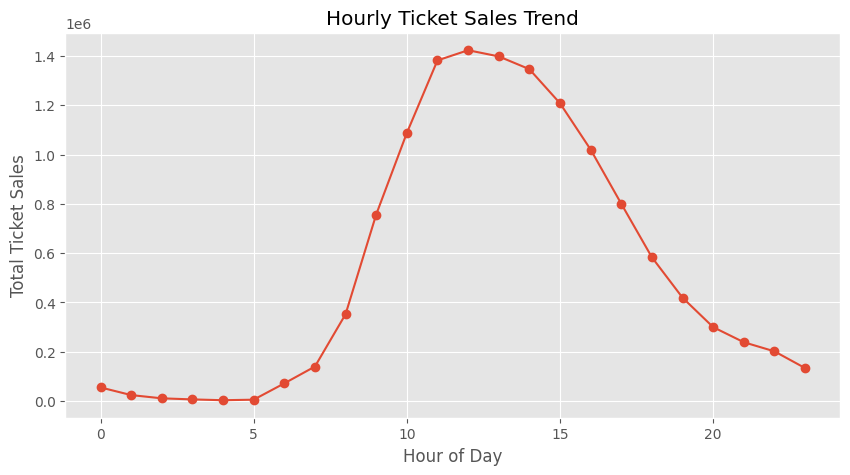

In [59]:
hourly_sales = (
    df.groupby("Hour")["Sales Count"]
    .sum())
plt.figure(figsize=(10,5))
hourly_sales.plot(kind="line", marker="o")
plt.title("Hourly Ticket Sales Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Total Ticket Sales")
plt.show()

**Insight**

This visualization highlights passenger demand fluctuations throughout the day. Hours with the highest ticket sales represent periods of increased ferry demand and may require additional ferry capacity.

**Hourly Ticket Redemption Analysis**

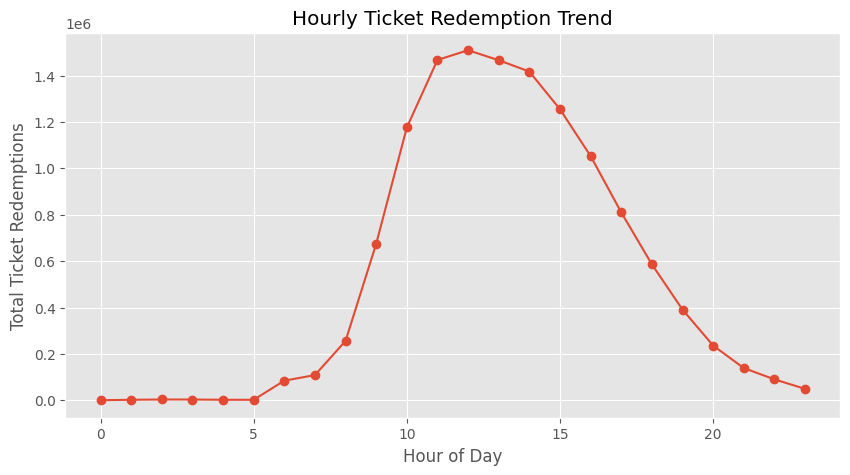

In [60]:
hourly_redemption = (
    df.groupby("Hour")["Redemption Count"]
    .sum())
plt.figure(figsize=(10,5))
hourly_redemption.plot(kind="line", marker="o")
plt.title("Hourly Ticket Redemption Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Total Ticket Redemptions")
plt.show()

**Insight**

Ticket redemptions represent actual passenger boarding activity. Comparing redemption patterns with sales trends helps identify passenger flow dynamics.

**Hourly Sales vs Redemption Comparison**

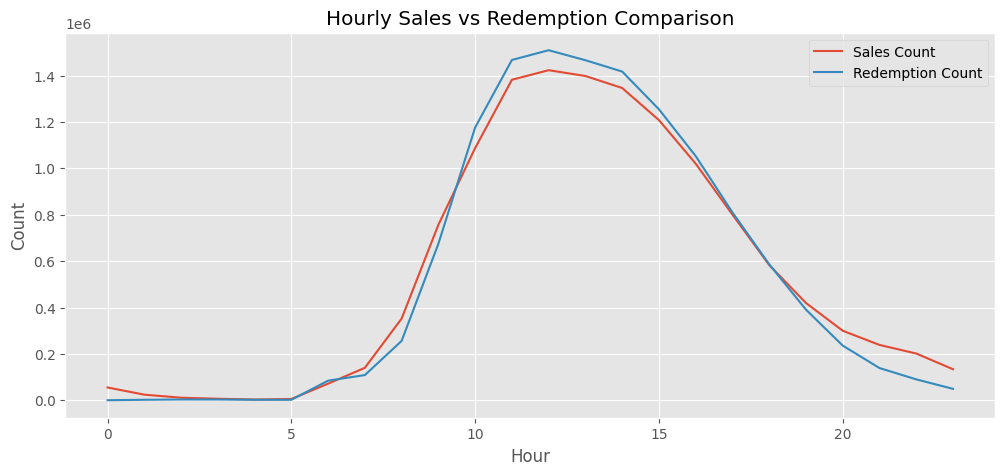

In [61]:
hourly_compare = (
    df.groupby("Hour")
    [["Sales Count","Redemption Count"]]
    .sum())
hourly_compare.plot(
    figsize=(12,5))
plt.title(
    "Hourly Sales vs Redemption Comparison")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

**Insight**

Comparing hourly ticket sales and redemption activity provides a comprehensive view of passenger demand and actual ferry usage. Similar patterns indicate efficient ticket utilization, while significant differences may reveal changing travel behavior or operational inefficiencies.

**Net Passenger Movement Analysis**

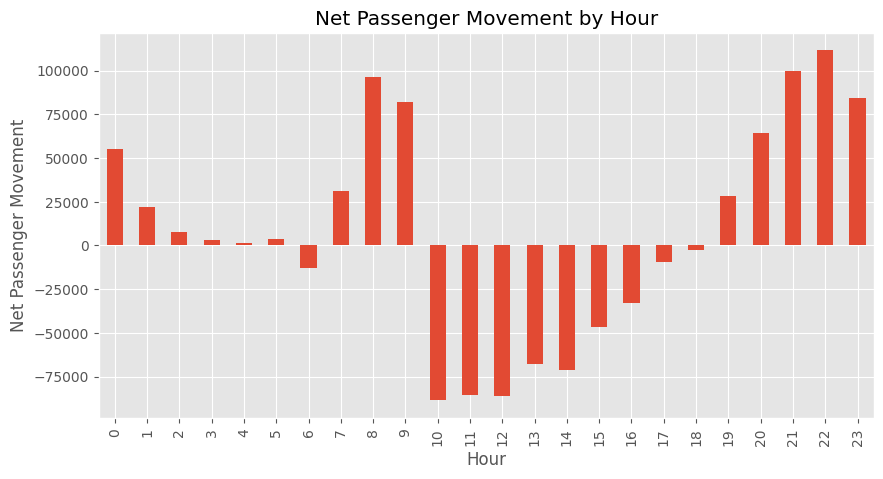

In [62]:
movement = (
    df.groupby("Hour")["Net Passenger Movement"].sum())
plt.figure(figsize=(10,5))
movement.plot(kind="bar")
plt.title("Net Passenger Movement by Hour")
plt.xlabel("Hour")
plt.ylabel("Net Passenger Movement")
plt.show()

**Insight**

Net Passenger Movement measures the difference between ticket sales and redemptions. Positive values indicate growing passenger inflow while negative values may indicate passenger departures exceeding new sales.

**Monthly Net Passenger Movement Analysis**

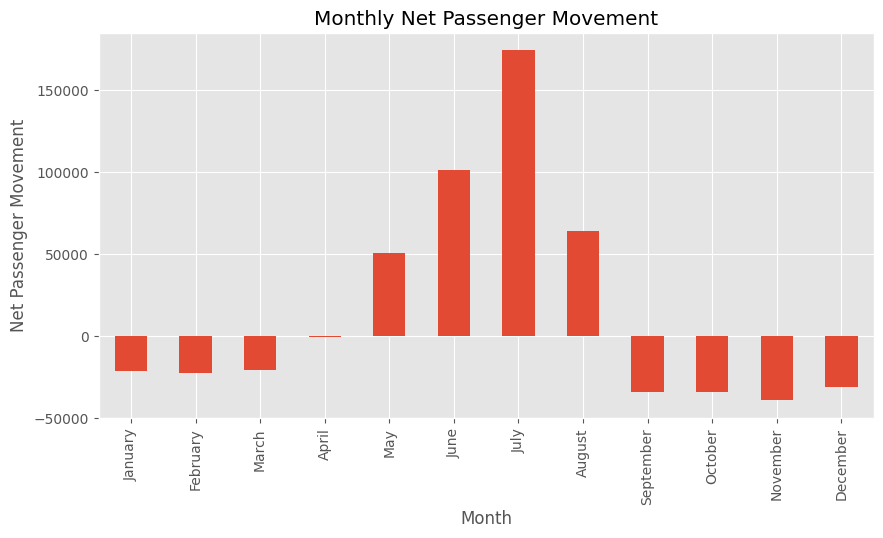

In [63]:
monthly_movement = (
    df.groupby("Month")
    ["Net Passenger Movement"]
    .sum()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"]))
monthly_movement.plot(
    kind="bar",
    figsize=(10,5))
plt.title("Monthly Net Passenger Movement")
plt.xlabel("Month")
plt.ylabel("Net Passenger Movement")
plt.show()

**Insight**

Monthly net passenger movement highlights periods of passenger accumulation and departure activity. Understanding these patterns helps improve terminal capacity planning and crowd management strategies.

**Daily Passenger Demand Analysis**

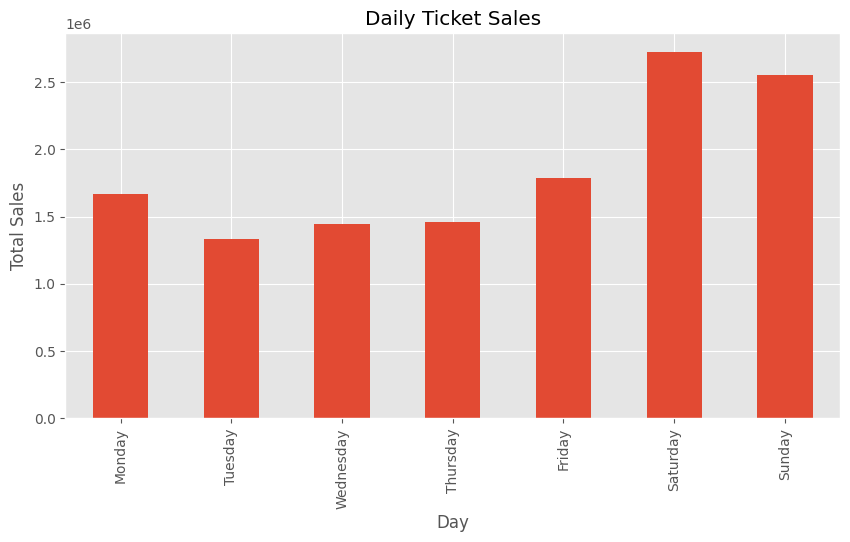

In [64]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"]
daily_sales = (
    df.groupby("Day")["Sales Count"]
    .sum()
    .reindex(day_order))
plt.figure(figsize=(10,5))
daily_sales.plot(kind="bar")
plt.title("Daily Ticket Sales")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.show()

**Insight**

Daily demand patterns reveal differences between weekday and weekend travel behavior. This information supports staffing and service planning.

**Weekend vs Weekday Comparison**

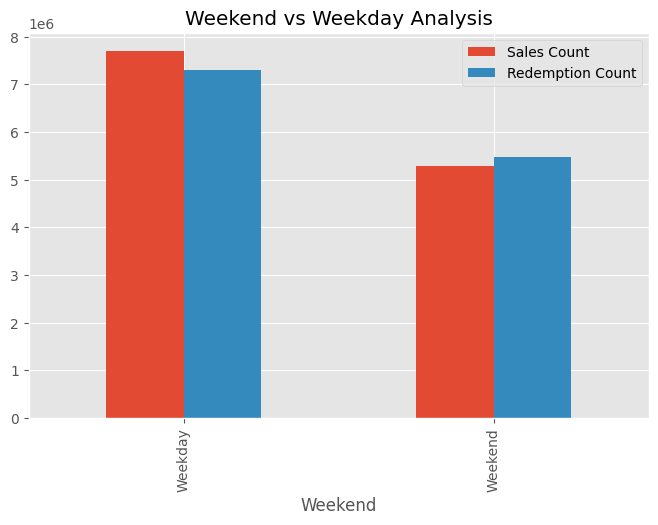

In [65]:
weekend_analysis = (
    df.groupby("Weekend")
    [["Sales Count","Redemption Count"]].sum())
weekend_analysis.plot(
    kind="bar",
    figsize=(8,5))
plt.title("Weekend vs Weekday Analysis")
plt.show()

**Insight**

Weekend and weekday demand patterns often differ significantly. Understanding these differences helps optimize ferry schedules and operational resources.

**Weekend vs Weekday Percentage Contribution**

In [66]:
contribution = (
    df.groupby("Weekend")
    ["Sales Count"]
    .sum())
percentage = (
    contribution /
    contribution.sum()) * 100
print(percentage.round(2))

Weekend
Weekday    59.31
Weekend    40.69
Name: Sales Count, dtype: float64


**Insight**

Percentage contribution analysis quantifies the share of passenger demand generated during weekdays and weekends, helping operators optimize staffing and scheduling decisions.

**Monthly Demand Trend Analysis**

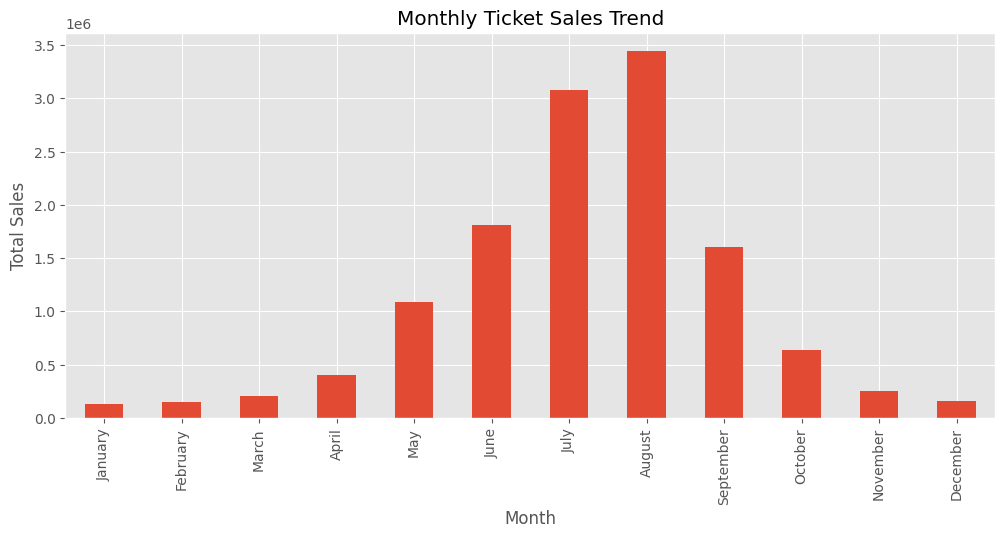

In [67]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"]
monthly_sales = (
    df.groupby("Month")["Sales Count"].sum().reindex(month_order))
plt.figure(figsize=(12,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Ticket Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

**Insight**

Monthly analysis helps identify seasonal demand patterns and tourism-driven travel behavior. High-demand months may require additional ferry services.

**Busiest Month Analysis**

In [98]:
busiest_month = monthly_sales.idxmax()
busiest_month_sales = monthly_sales.max()
print("Busiest Month:", busiest_month)
print("Total Ticket Sales:", busiest_month_sales)

Busiest Month: August
Total Ticket Sales: 3442762


**Insight**

August recorded the highest ticket sales volume, indicating the strongest passenger demand period. This month should receive priority for ferry capacity planning and staffing allocation.

**Quarter-wise Ticket Demand Analysis**

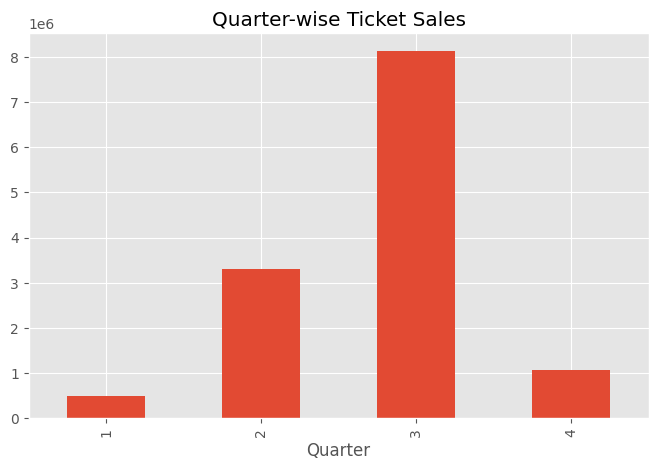

In [68]:
quarter_sales = (
    df.groupby("Quarter")["Sales Count"]
    .sum())
quarter_sales.plot(
    kind="bar",
    figsize=(8,5))
plt.title("Quarter-wise Ticket Sales")
plt.show()

**Insight**

Quarterly demand trends help identify broader business cycles and support long-term transportation planning and budgeting decisions.

**Yearly Demand Trend Analysis**

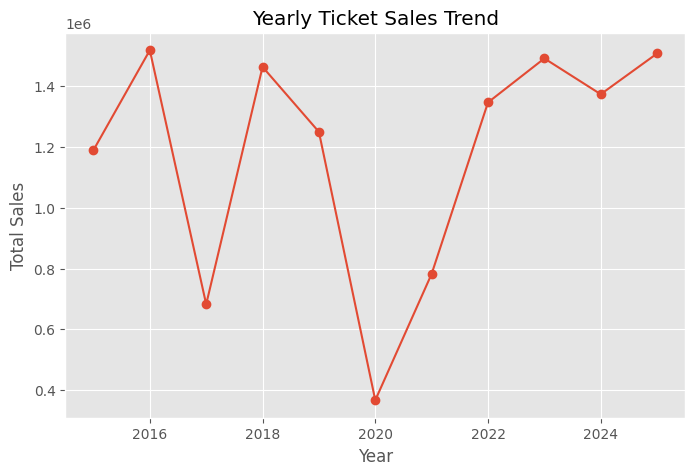

In [69]:
yearly_sales = (
    df.groupby("Year")["Sales Count"].sum())
plt.figure(figsize=(8,5))
yearly_sales.plot(
    kind="line",
    marker="o")
plt.title("Yearly Ticket Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

**Insight**

Year-over-year demand analysis helps identify long-term growth patterns and supports strategic transportation planning.

**Peak vs Off-Peak Passenger Activity**

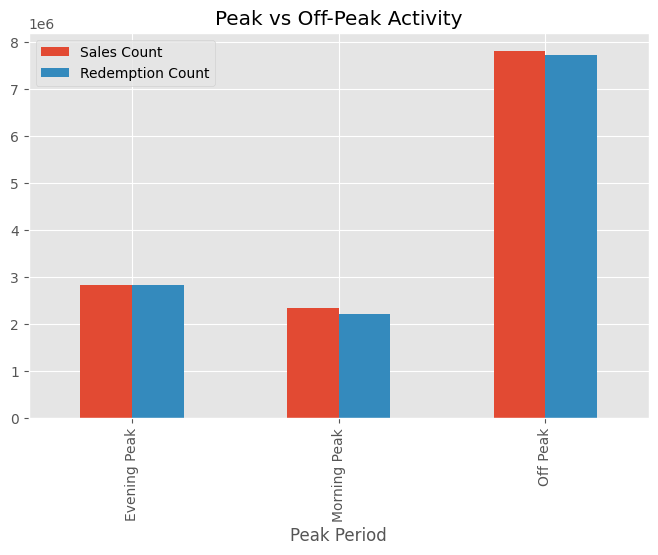

In [70]:
peak_analysis = (
    df.groupby("Peak Period")
    [["Sales Count","Redemption Count"]].sum())
peak_analysis.plot(
    kind="bar",
    figsize=(8,5))
plt.title("Peak vs Off-Peak Activity")
plt.show()

**Insight**

Peak-period analysis identifies operational pressure windows where ferry demand is concentrated. These periods may require additional vessels and staff deployment.

**Peak Period Contribution Analysis**

In [71]:
peak_contribution = (
    df.groupby("Peak Period")
    ["Sales Count"]
    .sum())
percentage = (
    peak_contribution /
    peak_contribution.sum()) * 100
print(percentage.round(2))

Peak Period
Evening Peak    21.77
Morning Peak    18.02
Off Peak        60.22
Name: Sales Count, dtype: float64


**Insight**

This analysis evaluates the proportion of passenger demand generated during peak and off-peak periods, supporting demand-based operational planning and capacity management.

**Top 10 Peak Demand Hours**

In [72]:
top_hours = (
    df.groupby("Hour")["Sales Count"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
top_hours

,Sales Count
Hour,
12,1423362
13,1398298
11,1382050
14,1346528
15,1208209
10,1087669
16,1020424
17,800584
9,756876


####**Statistical Analysis & Advanced Analytics**

**Correlation Analysis**

In [73]:
corr_matrix = df[[
        "Sales Count",
        "Redemption Count",
        "Net Passenger Movement"]].corr()
corr_matrix

,Sales Count,Redemption Count,Net Passenger Movement
Sales Count,1.000000,0.918163,0.092997
Redemption Count,0.918163,1.000000,-0.309100
Net Passenger Movement,0.092997,-0.309100,1.000000


**Insight**

Correlation analysis measures the strength and direction of relationships between operational variables. Strong correlations indicate variables that move together and can support operational planning decisions.

**Correlation Heatmap**

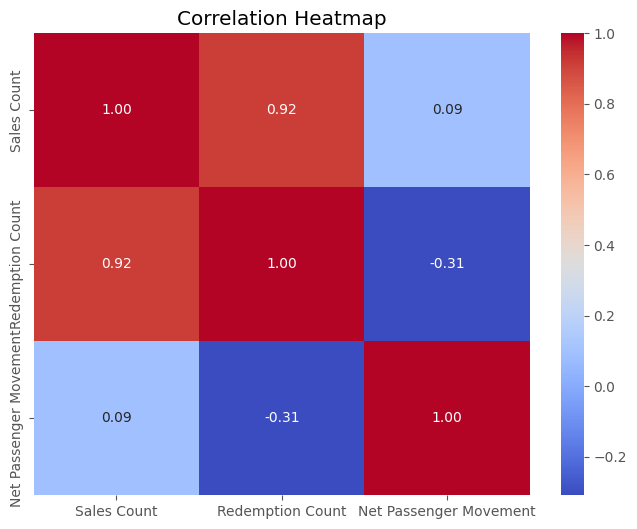

In [74]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Insight**

The heatmap visually highlights relationships among ticket sales, passenger redemptions, and net passenger movement. Understanding these relationships helps improve forecasting and demand management.

**Correlation Coefficient Interpretation**

In [75]:
sales_redemption = round(
    df["Sales Count"].corr(
        df["Redemption Count"]),2)
sales_movement = round(
    df["Sales Count"].corr(
        df["Net Passenger Movement"]),2)
redemption_movement = round(
    df["Redemption Count"].corr(
        df["Net Passenger Movement"]),2)
print(
    "Sales vs Redemption:",
    sales_redemption)
print(
    "Sales vs Net Passenger Movement:",
    sales_movement)
print(
    "Redemption vs Net Passenger Movement:",
    redemption_movement)

Sales vs Redemption: 0.92
Sales vs Net Passenger Movement: 0.09
Redemption vs Net Passenger Movement: -0.31


**Insight**

Correlation coefficients provide a quantitative measure of relationship strength. Values closer to +1 indicate strong positive relationships, while values near 0 indicate weak relationships.

**Statistical Significance Testing (Pearson Correlation Test)**

In [76]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    df["Sales Count"],
    df["Redemption Count"])
print("Correlation Coefficient:", round(corr,4))
print("P-value:", p_value)

Correlation Coefficient: 0.9182
P-value: 0.0


**Insight**

The Pearson correlation coefficient of 0.9182 indicates a very strong positive relationship between ticket sales and ticket redemptions. The p-value of 0.0 confirms that this relationship is statistically significant and not due to random variation. This suggests that increases in ticket sales are strongly associated with increases in passenger redemption activity, making ticket sales a reliable indicator of ferry demand.

**Rolling Average Analysis**

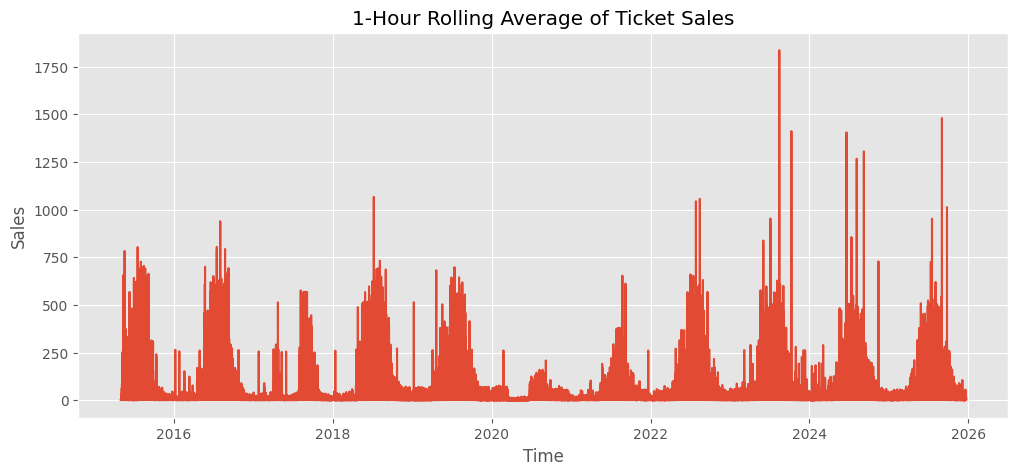

In [77]:
df["Sales_Rolling_1H"] = (
    df["Sales Count"]
    .rolling(window=4)
    .mean())
plt.figure(figsize=(12,5))
plt.plot(
    df["Timestamp"],
    df["Sales_Rolling_1H"])
plt.title(
    "1-Hour Rolling Average of Ticket Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

**Insight**

Rolling averages smooth short-term fluctuations and reveal underlying demand trends. This helps identify sustained increases or decreases in passenger activity.

**4-Hour Rolling Average Analysis**

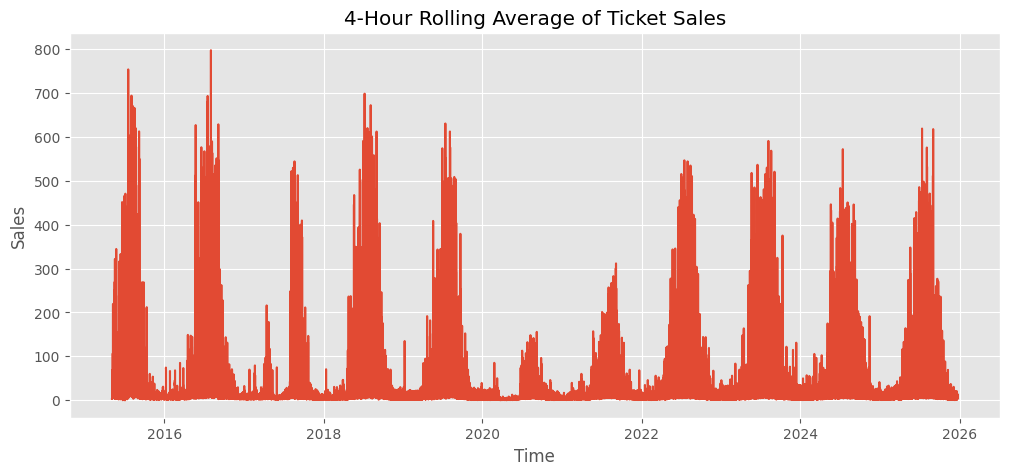

In [78]:
df["Sales_Rolling_4H"] = (
    df["Sales Count"]
    .rolling(window=16)
    .mean())
plt.figure(figsize=(12,5))
plt.plot(
    df["Timestamp"],
    df["Sales_Rolling_4H"])
plt.title(
    "4-Hour Rolling Average of Ticket Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

**Insight**

Longer rolling averages provide a clearer view of long-term demand behavior and help reduce noise from short-term fluctuations.

**Outlier Detection for Ticket Sales**

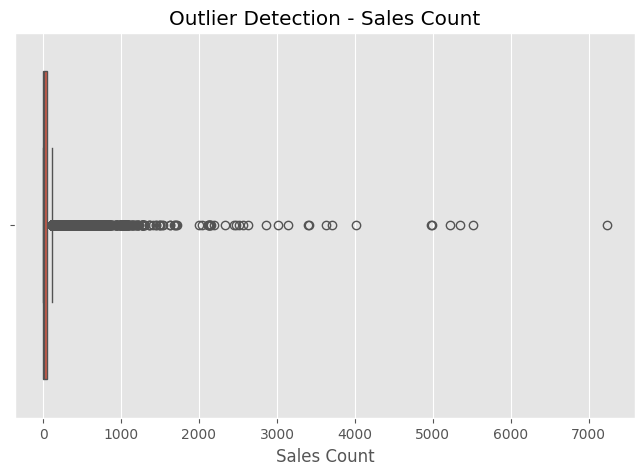

In [79]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Sales Count"])
plt.title(
    "Outlier Detection - Sales Count")
plt.show()

**Insight**

Outliers represent unusually high or low demand periods. Identifying these events helps ferry operators investigate special circumstances such as holidays, events, or service disruptions.

**Outlier Detection for Ticket Redemption**

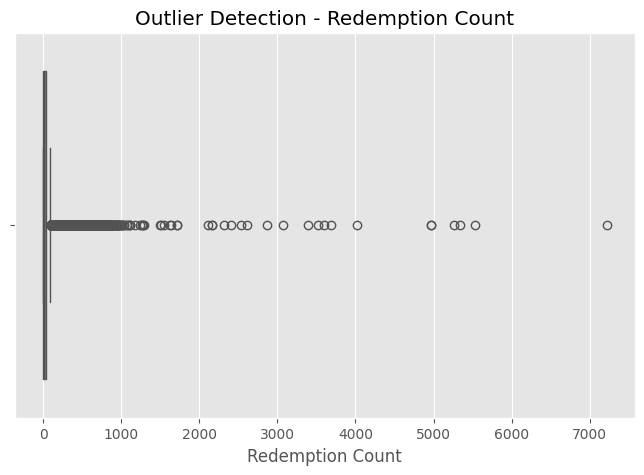

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Redemption Count"])
plt.title(
    "Outlier Detection - Redemption Count")
plt.show()

**Insight**

Extreme redemption activity may indicate significant passenger surges or operational events requiring additional resources.

**Demand Distribution Analysis**

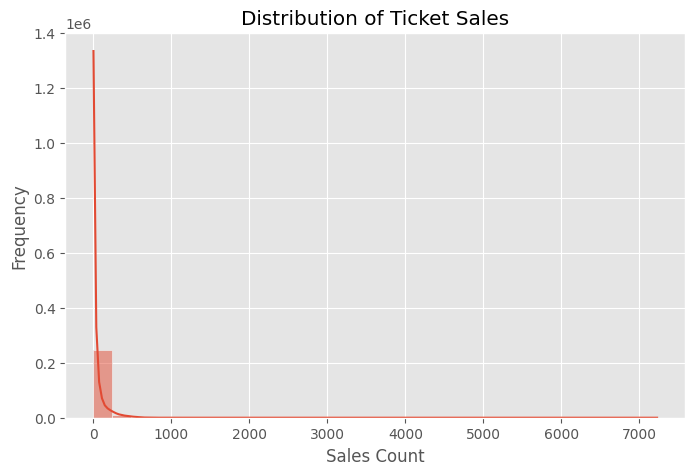

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Sales Count"],
    bins=30,
    kde=True)
plt.title("Distribution of Ticket Sales")
plt.xlabel("Sales Count")
plt.ylabel("Frequency")
plt.show()

**Insight**

The ticket sales distribution illustrates the frequency of passenger demand levels across the study period. The distribution helps identify common demand ranges and highlights the variability in ferry ticket purchases. Understanding demand distribution supports capacity planning and operational forecasting.

**Demand Volatility Analysis**

In [82]:
print("Sales Standard Deviation:",
      round(df["Sales Count"].std(),2))
print("Redemption Standard Deviation:",
      round(df["Redemption Count"].std(),2))

Sales Standard Deviation: 99.86
Redemption Standard Deviation: 104.55


**Insight**

Demand volatility measures the variability of passenger activity over time. Higher variability indicates periods of unpredictable demand that may require flexible scheduling and resource allocation.

**Redemption Distribution Analysis**

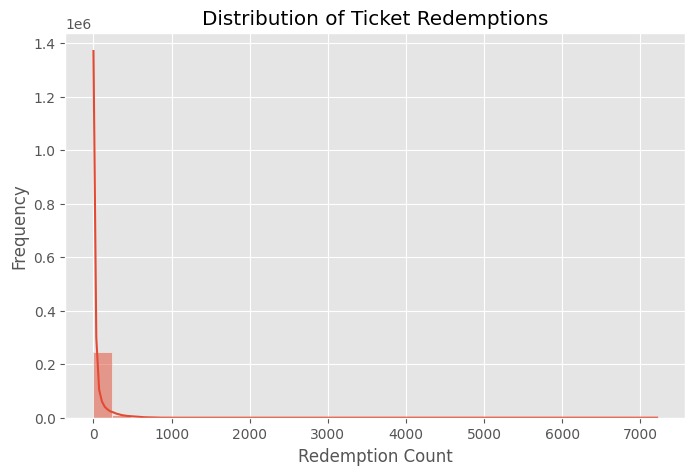

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Redemption Count"],
    bins=30,
    kde=True)
plt.title("Distribution of Ticket Redemptions")
plt.xlabel("Redemption Count")
plt.ylabel("Frequency")
plt.show()

**Insight**

The redemption distribution provides insight into actual passenger boarding behavior. Analyzing redemption frequency helps identify normal operational demand levels and periods of unusual passenger activity.

**Top 10 Highest Ticket Sales Records**

In [84]:
top_sales = (
    df[[
            "Timestamp",
            "Sales Count",
            "Redemption Count"]]
    .sort_values(
        by="Sales Count",
        ascending=False)
    .head(10))
top_sales

,Timestamp,Sales Count,Redemption Count
199913,2023-08-15 20:15:00,7229,7216
204264,2023-10-10 14:00:00,5518,5535
221390,2024-06-19 19:00:00,5342,5341
253769,2025-09-01 17:30:00,5218,5256
225326,2024-08-05 22:00:00,4995,4973
227997,2024-09-07 17:00:00,4974,4966
255572,2025-09-24 22:30:00,4015,4020
249886,2025-07-17 23:15:00,3701,3692
196497,2023-07-05 21:15:00,3634,3602
173649,2022-08-15 10:30:00,3408,3520


**Insight**

The highest sales intervals represent periods of exceptional demand and should be considered when planning future ferry capacity and scheduling.

**Top 10 Highest Redemption Records**

In [85]:
top_redemption = (
    df[[
            "Timestamp",
            "Sales Count",
            "Redemption Count"]]
    .sort_values(
        by="Redemption Count",
        ascending=False)
    .head(10))
top_redemption

,Timestamp,Sales Count,Redemption Count
199913,2023-08-15 20:15:00,7229,7216
204264,2023-10-10 14:00:00,5518,5535
221390,2024-06-19 19:00:00,5342,5341
253769,2025-09-01 17:30:00,5218,5256
225326,2024-08-05 22:00:00,4995,4973
227997,2024-09-07 17:00:00,4974,4966
255572,2025-09-24 22:30:00,4015,4020
249886,2025-07-17 23:15:00,3701,3692
196497,2023-07-05 21:15:00,3634,3602
173649,2022-08-15 10:30:00,3408,3520


**Insight**

The highest redemption periods reflect peak passenger boarding activity and provide valuable information for terminal resource allocation.

**Top 10 Peak Demand Dates**

In [86]:
df["Date"] = df["Timestamp"].dt.date
top_dates = (
    df.groupby("Date")
    ["Sales Count"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
print(top_dates)

Date
2016-08-01    25585
2018-07-01    23729
2015-07-18    23354
2016-07-16    23181
2018-08-05    22634
2025-07-12    22500
2016-09-04    22256
2016-06-18    21844
2018-08-11    21792
2015-08-16    21519
Name: Sales Count, dtype: int64


**Insight**

Peak demand dates reveal recurring periods of exceptionally high passenger traffic. These insights can support event planning, holiday scheduling, and operational preparedness.

**Seasonal Demand Analysis**

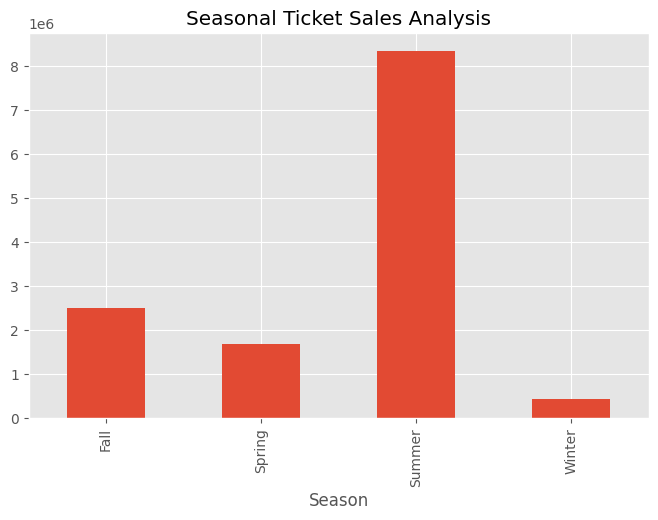

In [87]:
season_map = {
    "December":"Winter",
    "January":"Winter",
    "February":"Winter",
    "March":"Spring",
    "April":"Spring",
    "May":"Spring",
    "June":"Summer",
    "July":"Summer",
    "August":"Summer",
    "September":"Fall",
    "October":"Fall",
    "November":"Fall"}
df["Season"] = (
    df["Month"]
    .map(season_map))
seasonal_sales = (
    df.groupby("Season")
    ["Sales Count"]
    .sum())
seasonal_sales.plot(
    kind="bar",
    figsize=(8,5))
plt.title(
    "Seasonal Ticket Sales Analysis")
plt.show()

**Insight**

Seasonal analysis helps identify tourism-driven demand patterns and supports long-term operational planning and resource allocation.

**Peak Season vs Off-Season Demand Analysis**

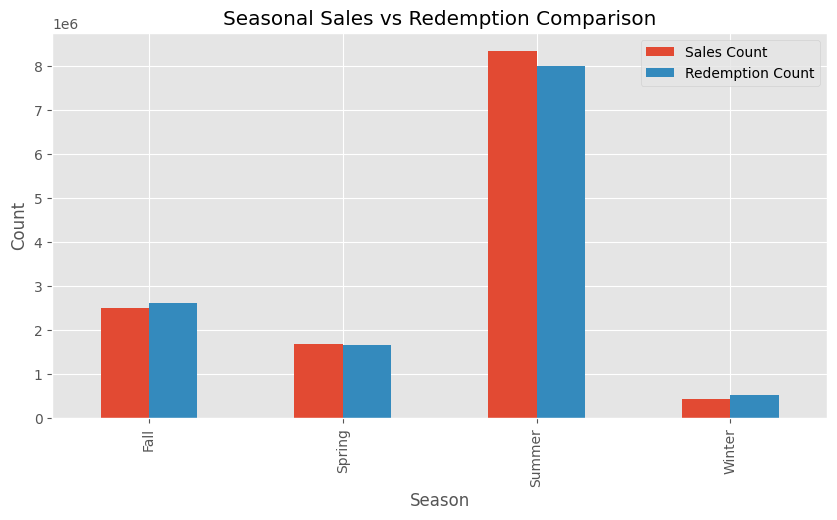

In [88]:
season_compare = (
    df.groupby("Season")
    [["Sales Count","Redemption Count"]]
    .sum())
season_compare.plot(
    kind="bar",
    figsize=(10,5))
plt.title("Seasonal Sales vs Redemption Comparison")
plt.xlabel("Season")
plt.ylabel("Count")
plt.show()

**Insight**

Comparing seasonal demand highlights tourism-driven passenger activity. Peak seasons experience significantly higher ferry usage and may require additional operational resources.

**Year-wise Sales vs Redemption Comparison**

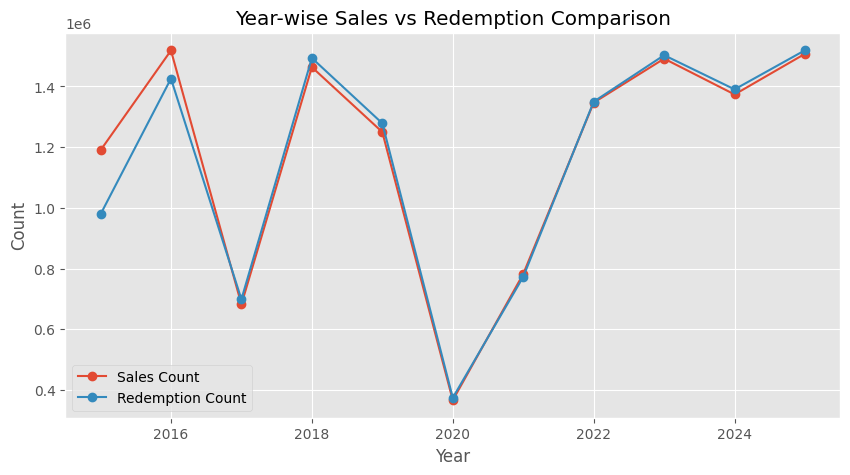

In [89]:
year_compare = (
    df.groupby("Year")[["Sales Count", "Redemption Count"]]
    .sum())
year_compare.plot(
    figsize=(10,5),
    marker="o")
plt.title("Year-wise Sales vs Redemption Comparison")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

**Insight**

The year-wise comparison demonstrates that ticket sales and ticket redemptions follow similar trends over time, indicating consistent passenger utilization of ferry services. The strong alignment between both metrics suggests stable operational performance and reliable demand forecasting potential.

**Year-over-Year Sales Growth Analysis**

In [90]:
yearly_sales = (
    df.groupby("Year")["Sales Count"]
    .sum())
growth = yearly_sales.pct_change() * 100
print("Year-over-Year Growth (%)")
print(growth.round(2))

Year-over-Year Growth (%)
Year
2015       NaN
2016     27.64
2017    -55.06
2018    114.49
2019    -14.61
2020    -70.67
2021    113.41
2022     72.13
2023     10.75
2024     -7.91
2025      9.76
Name: Sales Count, dtype: float64


**Insight**

Year-over-year growth analysis measures changes in passenger demand over time and provides valuable information for long-term transportation planning and resource allocation.

####**Executive Insights, Recommendations & Conclusion**

**Executive Dashboard Metrics**

In [91]:
peak_hour = (
    df.groupby("Hour")["Sales Count"]
    .sum()
    .idxmax())
peak_day = (
    df.groupby("Day")["Sales Count"]
    .sum()
    .idxmax())
peak_month = (
    df.groupby("Month")["Sales Count"]
    .sum()
    .idxmax())
print("Peak Demand Hour:", peak_hour)
print("Peak Demand Day:", peak_day)
print("Peak Demand Month:", peak_month)
print(
    "Average Ticket Sales:",
    round(df["Sales Count"].mean(),2))
print(
    "Average Ticket Redemptions:",
    round(df["Redemption Count"].mean(),2))

Peak Demand Hour: 12
Peak Demand Day: Saturday
Peak Demand Month: August
Average Ticket Sales: 49.6
Average Ticket Redemptions: 48.89


**Insight**

Executive metrics summarize the most important operational indicators and provide a quick overview of passenger demand behavior across the ferry system.

**Key Business Findings**

In [92]:
findings = [
    "Peak demand occurs during specific operating hours.",
    "Weekend demand differs significantly from weekday demand.",
    "Seasonal variations strongly influence passenger traffic.",
    "Sales and redemption counts exhibit strong operational relationships.",
    "Rolling averages reveal consistent long-term passenger demand trends.",
    "Peak periods create concentrated operational pressure windows."]
for i, finding in enumerate(findings, start=1):
    print(f"{i}. {finding}")

1. Peak demand occurs during specific operating hours.
2. Weekend demand differs significantly from weekday demand.
3. Seasonal variations strongly influence passenger traffic.
4. Sales and redemption counts exhibit strong operational relationships.
5. Rolling averages reveal consistent long-term passenger demand trends.
6. Peak periods create concentrated operational pressure windows.


**Insight**

These findings provide actionable knowledge that can support scheduling optimization, capacity planning, and passenger service improvements.

**Operational Recommendations**

In [93]:
recommendations = [
    "Increase ferry frequency during identified peak demand hours.",
    "Deploy additional staff during weekends and seasonal peaks.",
    "Use seasonal demand trends for long-term resource planning.",
    "Monitor real-time passenger movement to reduce congestion.",
    "Implement dynamic scheduling during high-demand periods.",
    "Use rolling average trends for operational forecasting.",
    "Strengthen capacity planning around major events and holidays.",
    "Develop automated demand monitoring dashboards."]
for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

1. Increase ferry frequency during identified peak demand hours.
2. Deploy additional staff during weekends and seasonal peaks.
3. Use seasonal demand trends for long-term resource planning.
4. Monitor real-time passenger movement to reduce congestion.
5. Implement dynamic scheduling during high-demand periods.
6. Use rolling average trends for operational forecasting.
7. Strengthen capacity planning around major events and holidays.
8. Develop automated demand monitoring dashboards.


**Insight**

Implementing these recommendations can improve passenger experience, optimize resource utilization, and support data-driven operational management.

**Business Impact Assessment**

In [94]:
impact = {
    "Operational Efficiency":
        "Improved through demand-based scheduling",

    "Passenger Experience":
        "Enhanced through reduced congestion",

    "Resource Allocation":
        "Optimized using demand analytics",

    "Decision Making":
        "Supported by real-time insights"}
pd.DataFrame(
    impact.items(),
    columns=[
        "Area",
        "Expected Impact"])

,Area,Expected Impact
0,Operational Efficiency,Improved through demand-based scheduling
1,Passenger Experience,Enhanced through reduced congestion
2,Resource Allocation,Optimized using demand analytics
3,Decision Making,Supported by real-time insights


**Insight**

The project demonstrates how data analytics can transform operational data into actionable business intelligence for transportation planning.

**Future Scope**

In [95]:
future_scope = [
    "Demand forecasting using machine learning models.",
    "Real-time passenger monitoring systems.",
    "Weather-based demand prediction.",
    "Special event demand forecasting.",
    "Dynamic pricing strategy analysis.",
    "Automated operational alert systems."]
for item in future_scope:
    print("-", item)

- Demand forecasting using machine learning models.
- Real-time passenger monitoring systems.
- Weather-based demand prediction.
- Special event demand forecasting.
- Dynamic pricing strategy analysis.
- Automated operational alert systems.


**Insight**

Future enhancements can extend the analytical framework from descriptive analytics to predictive and prescriptive decision support systems.

**Executive Summary**

- The analysis of Toronto Island Ferry ticket sales and redemption data identified significant passenger demand patterns across hourly, daily, monthly, and seasonal dimensions.

- Peak demand periods were successfully identified, enabling targeted operational planning and resource allocation. Statistical analysis revealed meaningful relationships between ticket sales, passenger redemptions, and net passenger movement. Rolling average analysis provided deeper visibility into long-term demand behavior, while outlier detection highlighted exceptional operational events.

- The findings support improved ferry scheduling, enhanced passenger experience, optimized staffing decisions, and more efficient transportation planning.

**Final KPI Summary Table**

In [96]:
summary = {
    "Metric":[
        "Total Ticket Sales",
        "Total Ticket Redemptions",
        "Net Passenger Movement",
        "Peak Demand Hour",
        "Peak Demand Day",
        "Peak Demand Month"],
    "Value":[
        df["Sales Count"].sum(),
        df["Redemption Count"].sum(),
        df["Net Passenger Movement"].sum(),
        peak_hour,
        peak_day,
        peak_month]}
pd.DataFrame(summary)

,Metric,Value
0,Total Ticket Sales,12972051
1,Total Ticket Redemptions,12785293
2,Net Passenger Movement,186758
3,Peak Demand Hour,12
4,Peak Demand Day,Saturday
5,Peak Demand Month,August


**Insight**

The KPI summary consolidates the most important operational metrics identified throughout the analysis. These indicators provide management with a concise overview of system performance and passenger demand behavior.

**Conclusion**

- This project successfully analyzed real-time ferry ticket sales and redemption activity for Toronto Island Park using advanced exploratory data analysis, statistical techniques, and operational performance evaluation.

- The study identified passenger demand trends, peak activity periods, seasonal patterns, and key operational insights. The results demonstrate the value of data-driven decision-making for improving ferry service efficiency, resource utilization, and passenger satisfaction.

- The analytical framework developed in this project can serve as a foundation for future forecasting, automation, and intelligent transportation management initiatives.

**Project Completion Summary**

In [97]:
project_summary = {
    "Data Cleaning": "Completed",
    "Feature Engineering": "Completed",
    "Exploratory Data Analysis": "Completed",
    "Statistical Analysis": "Completed",
    "Correlation Analysis": "Completed",
    "Rolling Average Analysis": "Completed",
    "Outlier Detection": "Completed",
    "Seasonal Analysis": "Completed",
    "Business Recommendations": "Completed",
    "Executive Summary": "Completed"}
pd.DataFrame(
    project_summary.items(),
    columns=["Task", "Status"])

,Task,Status
0,Data Cleaning,Completed
1,Feature Engineering,Completed
2,Exploratory Data Analysis,Completed
3,Statistical Analysis,Completed
4,Correlation Analysis,Completed
5,Rolling Average Analysis,Completed
6,Outlier Detection,Completed
7,Seasonal Analysis,Completed
8,Business Recommendations,Completed
9,Executive Summary,Completed
